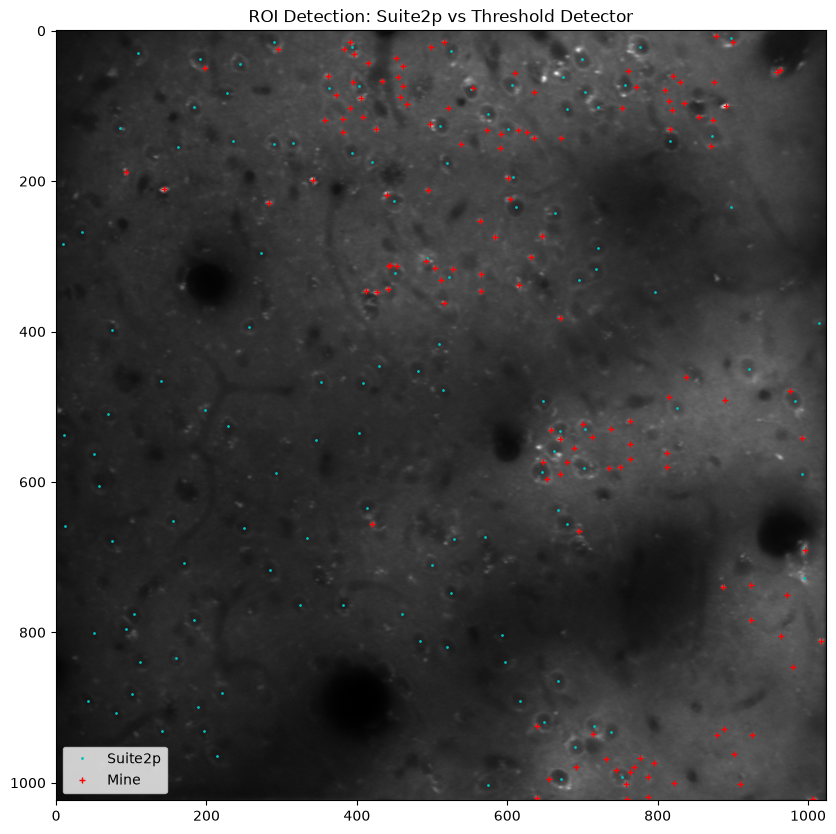

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter, label, find_objects

# Paths
data_dir = Path('/projectnb2/npcr25/projects/two_photon/Ex1_jRGECO1a_ResonantScanning/processed')
run_dir = data_dir / 'TSeries-03042024-run02-054'

# Load data
stat = np.load(run_dir / 'stat.npy', allow_pickle=True)
ops = np.load(run_dir / 'ops.npy', allow_pickle=True).item()
mean_img = ops['meanImg']

# 1. Implement threshold-based detector
# Smooth image to reduce noise
img_smoothed = gaussian_filter(mean_img, sigma=2)

# Apply threshold (simple percentile-based)
threshold = np.percentile(img_smoothed, 95)
mask = img_smoothed > threshold

# Label blobs
labeled_mask, num_features = label(mask)
slices = find_objects(labeled_mask)

# Get centroids of detected blobs
my_centroids = []
for s in slices:
    if s is None: continue
    y_slice, x_slice = s
    my_centroids.append(( (y_slice.start + y_slice.stop - 1)/2, (x_slice.start + x_slice.stop - 1)/2 ))
my_centroids = np.array(my_centroids)

# 2. Visualize
plt.figure(figsize=(10, 10))
plt.imshow(mean_img, cmap='gray')
# Suite2p ROIs
for s in stat:
    plt.plot(s['med'][1], s['med'][0], 'c.', markersize=2, label='Suite2p' if s is stat[0] else "")
# My ROIs
plt.plot(my_centroids[:, 1], my_centroids[:, 0], 'r+', markersize=5, label='Mine')
plt.legend()
plt.title('ROI Detection: Suite2p vs Threshold Detector')
plt.show()